In [4]:
!pip install emoji
!pip install spacy
!python -m spacy download es_core_news_sm


[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 33.9 MB/s eta 0:00:0031m35.4 MB/s eta 0:00:01

[notice] A new release of pip is available: 25.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


# Analisis de grupo de whatsapp

En esta actividad se realizará un análisis exploratorio de datos (EDA) de un grupo de whatsapp. Se analizarán los mensajes del grupo, los participantes y la actividad del grupo a lo largo del tiempo. Para este caso, se tomó el grupo de whatsapp de mi familia, el cual tiene 21 participantes y mas de 10k mensajes.

# TODO: Anonimizar los nombres en los mensajes

## Importando librerías

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import spacy
import seaborn as sns
import numpy as np
from pathlib import Path
import re
import emoji
import random
from collections import Counter
import wordcloud

nlp = spacy.load("es_core_news_sm")

## Importando datos

Los datos descargados vienen en formato txt

In [6]:
ruta = Path("data/_chat.txt")

patron = re.compile(
    r"^[\u200e\u200f]?\[(?P<fecha>\d{1,2}/\d{1,2}/\d{2}),\s*"
    r"(?P<hora>\d{1,2}:\d{2}:\d{2})\s*(?P<ampm>[ap])\.m\.\]\s*"
    r"(?P<remitente>[^:]+):\s*(?P<mensaje>.*)$",
    re.IGNORECASE,
)

registros = []

for linea in ruta.read_text(encoding="utf-8-sig").splitlines():
    match = patron.match(linea)
    
    if match:
        registros.append(match.groupdict())
    elif registros:
        # Une líneas que pertenecen al mensaje anterior
        registros[-1]["mensaje"] += "\n" + linea

chat = pd.DataFrame(registros)

chat["fecha_hora"] = pd.to_datetime(
    chat["fecha"] + " " + chat["hora"] + " " + chat["ampm"].str.upper() + "M",
    format="%d/%m/%y %I:%M:%S %p"
)

chat["fecha"] = chat["fecha_hora"].dt.date
chat["hora"] = chat["fecha_hora"].dt.hour
chat["dia_semana"] = chat["fecha_hora"].dt.day_name()
chat["longitud_mensaje"] = chat["mensaje"].str.len()
chat["es_multimedia"] = chat["mensaje"].str.contains(
    r"(image|video|audio|sticker|GIF) omitted", case=False, na=False
)

personajes_star_wars = [
    "Luke Skywalker", "Leia Organa", "Han Solo", "Chewbacca",
    "Yoda", "Obi-Wan Kenobi", "Anakin Skywalker", "Padmé Amidala",
    "Darth Vader", "Emperador Palpatine", "R2-D2", "C-3PO",
    "Ahsoka Tano", "Mandalorian", "Grogu", "Rey",
    "Finn", "Poe Dameron", "Lando Calrissian", "Mace Windu",
    "Qui-Gon Jinn", "Darth Maul", "Conde Dooku", "Jyn Erso",
    "Cassian Andor", "K-2SO", "Bo-Katan Kryze", "Boba Fett",
    "Fennec Shand", "Kit Fisto"
]

# Semilla fija: el mismo remitente siempre recibirá el mismo personaje
random.seed(42)

remitentes = chat["remitente"].dropna().unique().tolist()

if len(remitentes) > len(personajes_star_wars):
    raise ValueError("Faltan personajes para anonimizar todos los remitentes.")

random.shuffle(personajes_star_wars)

mapa_anonimizacion = dict(zip(remitentes, personajes_star_wars))

chat["remitente_anonimo"] = chat["remitente"].map(mapa_anonimizacion)

# Opcional: elimina el nombre real del DataFrame de análisis
chat = chat.drop(columns="remitente").rename(
    columns={"remitente_anonimo": "remitente"}
)

/var/folders/bt/nvzckywj42s3jj55fjzzjdm80000gn/T/ipykernel_88220/3325842239.py:32: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  chat["es_multimedia"] = chat["mensaje"].str.contains(


In [7]:
def anonimizar_nombres(doc):
    texto = doc.text
    for ent in reversed(doc.ents):
        if ent.label_ == "PER":
            texto = texto[:ent.start_char] + "anonimo" + texto[ent.end_char:]
    return texto

chat["mensaje"] = [anonimizar_nombres(doc) for doc in nlp.pipe(chat["mensaje"].fillna(""))]

chat.head()

,fecha,hora,ampm,mensaje,fecha_hora,dia_semana,longitud_mensaje,es_multimedia,remitente
0,2025-07-13,7,a,Buenos días familia,2025-07-13 07:57:26,Sunday,19,False,Mace Windu
1,2025-07-13,9,a,felicidades julitooo,2025-07-13 09:37:06,Sunday,20,False,Grogu
2,2025-07-13,9,a,Muchas felicidades julito q dios te conceda mu...,2025-07-13 09:40:57,Sunday,71,False,Mace Windu
3,2025-07-13,10,a,anonimo felicidades Jr!! Que tengas una larga ...,2025-07-13 10:31:33,Sunday,131,False,R2-D2
4,2025-07-13,10,a,anonimo hijo que dios te de una maravillosa vi...,2025-07-13 10:48:04,Sunday,70,False,Bo-Katan Kryze


In [8]:
chat = chat.drop('ampm', axis=1, inplace=False)
chat.head()

,fecha,hora,mensaje,fecha_hora,dia_semana,longitud_mensaje,es_multimedia,remitente
0,2025-07-13,7,Buenos días familia,2025-07-13 07:57:26,Sunday,19,False,Mace Windu
1,2025-07-13,9,felicidades julitooo,2025-07-13 09:37:06,Sunday,20,False,Grogu
2,2025-07-13,9,Muchas felicidades julito q dios te conceda mu...,2025-07-13 09:40:57,Sunday,71,False,Mace Windu
3,2025-07-13,10,anonimo felicidades Jr!! Que tengas una larga ...,2025-07-13 10:31:33,Sunday,131,False,R2-D2
4,2025-07-13,10,anonimo hijo que dios te de una maravillosa vi...,2025-07-13 10:48:04,Sunday,70,False,Bo-Katan Kryze


## Analisis exploratorio de datos

In [9]:
# Son 4777 mensajes cada uno con 8 caracteristicas
print(chat.shape)

# No tenemos valores nulos en ninguna de las caracteristicas y podemos ver el valor de cada una de las columnas
print(chat.info())


(4777, 8)
<class 'pandas.DataFrame'>
RangeIndex: 4777 entries, 0 to 4776
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             4777 non-null   object        
 1   hora              4777 non-null   int32         
 2   mensaje           4777 non-null   str           
 3   fecha_hora        4777 non-null   datetime64[us]
 4   dia_semana        4777 non-null   str           
 5   longitud_mensaje  4777 non-null   int64         
 6   es_multimedia     4777 non-null   bool          
 7   remitente         4777 non-null   str           
dtypes: bool(1), datetime64[us](1), int32(1), int64(1), object(1), str(3)
memory usage: 247.4+ KB
None


## Contestando preguntas

### 1. ¿Cuál es el usuario que más mensajes envía?

En la siguiente tabla se ordenan los usuarios por cantidad de mensajes enviados, ordenados de mayor a menor. Aqui se puede observar que el usuario que mas mensajes envió fue R2-D2 con un total de 943, seguido de C-3PO con 868 y Conde Dooku con 668.

In [10]:
total_msm_count = chat.groupby('remitente').agg(
    total_mensajes=('mensaje', 'count')
).sort_values(by='total_mensajes', ascending=False)

total_msm_count.head()

,total_mensajes
remitente,
R2-D2,943
C-3PO,868
Conde Dooku,668
Mace Windu,598
Bo-Katan Kryze,457


In [11]:
total_msm_count.tail()

,total_mensajes
remitente,
Emperador Palpatine,14
K-2SO,11
Obi-Wan Kenobi,10
Yoda,3
Mandalorian,2


En la siguiente grafica de barras se puede observar la cantidad de mensajes enviados por cada usuario.

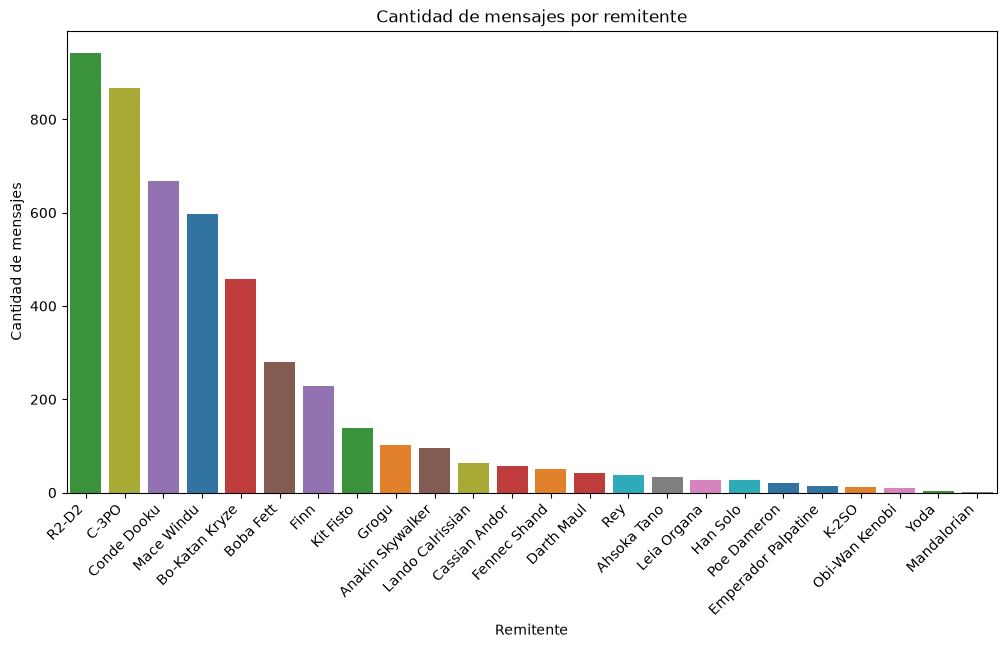

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=chat, x='remitente', order=chat['remitente'].value_counts().index,
              hue='remitente', palette='tab10')

plt.title('Cantidad de mensajes por remitente')
plt.xlabel('Remitente')
plt.ylabel('Cantidad de mensajes')
plt.xticks(rotation=45, ha='right') 

plt.show()


### 2. ¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?

En la siguiente tabla se muestran el top 5 de usuarios con mayor promedio de palabras por mensaje de texto. Se observa un cambio con respecto a la pregunta anterior, lo que nos puede decir que no por mandar mas mensajes, se tiene un mayor promedio de palabras por mensaje, de hecho probablemente sea lo contrario. En este caso, el usuario que tiene un mayor promedio de palabras por mensaje es Grougu con 54.42 palabras por mensaje que ni siquiera aparecio en el top 5 de la pregunta anterior.

In [13]:
promedio_palabras = chat.groupby('remitente').agg(
    promedio_palabras=('longitud_mensaje', 'mean')
).sort_values(by='promedio_palabras', ascending=False)

promedio_palabras.head()

,promedio_palabras
remitente,
Grogu,54.425743
R2-D2,46.001060
Emperador Palpatine,45.071429
Mandalorian,39.000000
Kit Fisto,38.985507


In [14]:
promedio_palabras.tail()

,promedio_palabras
remitente,
Bo-Katan Kryze,24.118162
Rey,23.864865
Mace Windu,20.102007
K-2SO,18.181818
Fennec Shand,17.823529


### 3.1 ¿Cuál es el usuario que más palabras envía? 

Como vimos en la pregunta anterior, el usuario que más palabras envía en promedio es Grougu.

In [15]:
# Cuantos mensajes ha mandado Grougu? Es representativo?
print(total_msm_count[total_msm_count.index == 'Grogu']['total_mensajes'])

remitente
Grogu    101
Name: total_mensajes, dtype: int64


#### Y cual es el usuario que ha mandado el mensaje con mas palabras?

Parece que fue C-3PO con un mensaje de casi 2000 palabras, el 20 de febrero de este año. Veamos que dice

In [16]:
mensaje_mas_largo = chat.loc[chat['longitud_mensaje'] == chat['longitud_mensaje'].max()]
mensaje_mas_largo

,fecha,hora,mensaje,fecha_hora,dia_semana,longitud_mensaje,es_multimedia,remitente
2548,2026-02-20,10,Se acabó el ayuno de anonimo en Cuaresma (Fina...,2026-02-20 10:46:42,Friday,1906,False,C-3PO


In [17]:
print(mensaje_mas_largo['mensaje'].values[0])

Se acabó el ayuno de anonimo en Cuaresma (Finalmente!!)
Ya vieron que belleza:
El *anonimo* propone 15 sencillos actos de *caridad* que él ha mencionado como manifestaciones concretas del *amor de anonimo

💠1.saludar. (siempre y en todo lugar)

 💠2. Dar las *gracias* (aunque no "debas" hacerlo).

 💠3. anonimo a los demás cuanto los *amas.*

 💠4. *Saludar con alegría* a esas personas que ves a diario.

 💠5. Escuchar la *historia* del otro, sin prejuicios, *con amor*.

 💠6. anonimo para *ayudar*. Estar *atento a quien te necesita.*

 💠7. *Levantarle los ánimos* a alguien.

 💠8. *Celebrar* las *cualidades* o *éxitos* de otro.

 💠9. *Seleccionar* lo que no usas y *regalarlo* a quien lo necesita.

 💠10. *Ayudar cuando se necesite* para que otro descanse.

 💠11. *Corregir con amor,* no callar por miedo.

 💠12. *Tener buenos detalles* con los que están *cerca de ti.*

 💠13. *Limpiar lo que uso en casa.*

 💠14. *Ayudar a los demás a superar obstáculos*.

 💠15. *Llamar por teléfono a tus padres

### 3.2 ¿Y el que envía más emojis? 

Para este caso creamos una nueva columna para guardar la cantidad de emojis por cada mensaje, y luego agrupamos por usuario para obtener la cantidad total de emojis enviados por cada uno. En la siguiente tabla se puede observar que el usuario que más emojis envió fue R2-D2 con un total de 749 emojis.

In [18]:
# Obteniendo la cantidad de emojis por mensaje
chat_w_emojis = chat.copy()
#Encuentra caracteres que NO sean letras/números (\w), espacios (\s) o comas.
chat_w_emojis['cantidad_emojis'] = chat_w_emojis['mensaje'].apply(lambda x: emoji.emoji_count(x))
chat_w_emojis[chat_w_emojis['cantidad_emojis'] > 0].head(2)

,fecha,hora,mensaje,fecha_hora,dia_semana,longitud_mensaje,es_multimedia,remitente,cantidad_emojis
3,2025-07-13,10,anonimo felicidades Jr!! Que tengas una larga ...,2025-07-13 10:31:33,Sunday,131,False,R2-D2,5
6,2025-07-13,11,Mil felicidades Jr!! Que anonimo te colme de s...,2025-07-13 11:03:31,Sunday,160,False,Conde Dooku,2


In [19]:
chat_w_emojis[6:7]['mensaje'].values[0]

'Mil felicidades Jr!! Que anonimo te colme de salud, amor, paciencia , larga y maravillosa vida. Te queremos mucho aunque siempre estés en la lista renegrida anonimo🎁🎂anonimo'

In [20]:
emoji_count = chat_w_emojis.groupby('remitente').agg(
    total_emojis=('cantidad_emojis', 'sum')
).sort_values(by='total_emojis', ascending=False)

print("Top 5")
print(emoji_count.head())
print("--" * 20)
print("Últimos 5")
print(emoji_count.tail())


Top 5
             total_emojis
remitente                
R2-D2                 613
Conde Dooku           476
Boba Fett             192
C-3PO                 138
Finn                   49
----------------------------------------
Últimos 5
                     total_emojis
remitente                        
Mace Windu                      1
Poe Dameron                     1
Grogu                           0
Leia Organa                     0
Emperador Palpatine             0


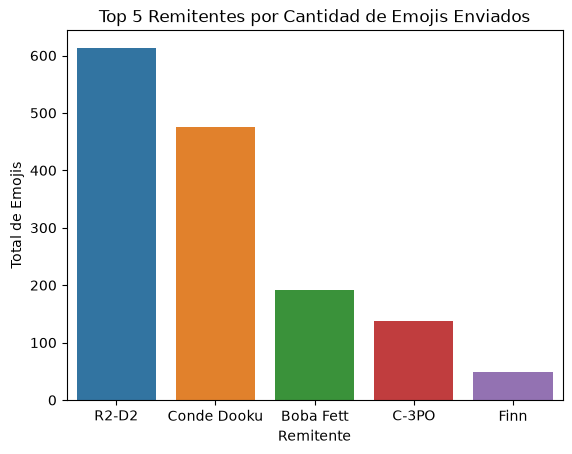

In [21]:
top_5 = emoji_count.head(5)
sns.barplot(data=top_5.reset_index(), x='remitente', y='total_emojis', 
            order=top_5.reset_index()['remitente'], hue='remitente', palette='tab10')

plt.title('Top 5 Remitentes por Cantidad de Emojis Enviados')
plt.xlabel('Remitente')
plt.ylabel('Total de Emojis')
plt.show()


### 3.3 ¿Y el que envía más *stickers*?

Aquí pasa algo muy curioso por que podemos ver como hay dos personas que han enviado una gran cantidad de *stickers* en comparación con los demas que no suelen mandar tanto. En este caso el segundo usuario que mas ha mandado stickers (Conde Dooku) ha mandado casi 17 veces mas que el tercer lugar. 

In [22]:
chat_w_stickers = chat.copy()
chat_w_stickers["es_sticker"] = chat_w_stickers["mensaje"].str.contains(
    r"sticker omitted",
    case=False,
    na=False
)

chat_w_stickers[chat_w_stickers["es_sticker"] == True].head(3)


,fecha,hora,mensaje,fecha_hora,dia_semana,longitud_mensaje,es_multimedia,remitente,es_sticker
46,2025-07-15,13,‎sticker omitted,2025-07-15 13:23:58,Tuesday,16,True,R2-D2,True
50,2025-07-16,10,‎sticker omitted,2025-07-16 10:31:56,Wednesday,16,True,R2-D2,True
109,2025-07-21,10,‎sticker omitted,2025-07-21 10:55:54,Monday,16,True,Boba Fett,True


In [23]:
sticker_count = chat_w_stickers.groupby('remitente').agg(
    total_stickers=('es_sticker', 'sum')
).sort_values(by='total_stickers', ascending=False)

print("Top 5")
print(sticker_count.head())
print("--" * 20)
print("Últimos 5")
print(sticker_count.tail())


Top 5
             total_stickers
remitente                  
R2-D2                   232
Conde Dooku             196
Boba Fett                12
Finn                      9
Leia Organa               9
----------------------------------------
Últimos 5
                     total_stickers
remitente                          
K-2SO                             0
Fennec Shand                      0
Emperador Palpatine               0
Bo-Katan Kryze                    0
Yoda                              0


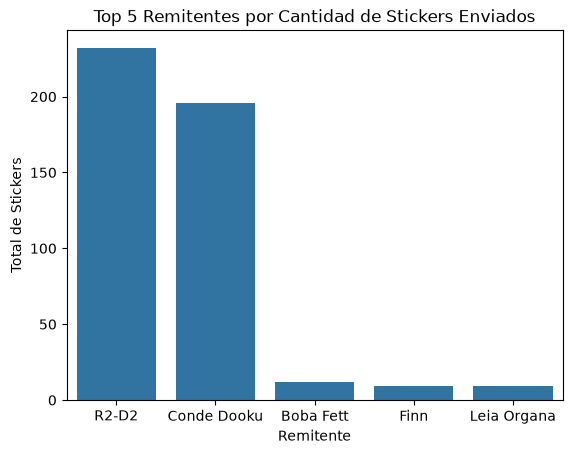

In [24]:
top_5 = sticker_count.head(5)
sns.barplot(data=top_5.reset_index(), x='remitente', y='total_stickers', order=top_5.reset_index()['remitente'])

plt.title('Top 5 Remitentes por Cantidad de Stickers Enviados')
plt.xlabel('Remitente')
plt.ylabel('Total de Stickers')
plt.show()


### 4.1 ¿Que días de la semana se mandan más mensajes y cuales menos?

Si buscamos por número total de mensajes enviados, podemos observar qué días de la semana son los más activos y cuáles los menos. En este caso, los días que mas se mandaron mensajes en total fueron los jueves, seguido del viernes y miercoles. Por otro lado, los días con menor actividad fueron los sabados y martes.

dia_semana
Thursday     765
Friday       748
Wednesday    698
Sunday       695
Monday       668
Saturday     636
Tuesday      567
Name: count, dtype: int64


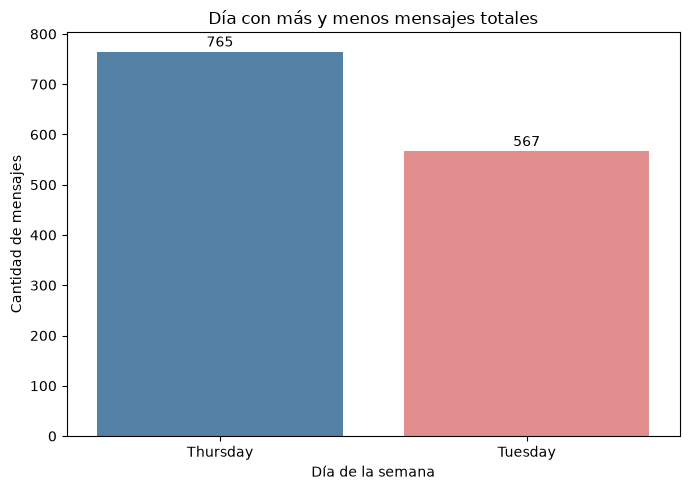

,dia,cantidad_mensajes
0,Thursday,765
1,Tuesday,567


In [25]:
print(chat['dia_semana'].value_counts())

max_and_min_msg_days = {
    'max': chat['dia_semana'].value_counts().idxmax(),
    'max_count': chat['dia_semana'].value_counts().max(),
    'min': chat['dia_semana'].value_counts().idxmin(),
    'min_count': chat['dia_semana'].value_counts().min()
}

max_and_min_msg_days = pd.DataFrame([max_and_min_msg_days])
max_and_min_msg_days


# Comparación entre el día con más y menos mensajes
comparacion_dias = pd.DataFrame({
    'dia': [max_and_min_msg_days.loc[0, 'max'], max_and_min_msg_days.loc[0, 'min']],
    'cantidad_mensajes': [
        max_and_min_msg_days.loc[0, 'max_count'],
        max_and_min_msg_days.loc[0, 'min_count']
    ]
})

plt.figure(figsize=(7, 5))
sns.barplot(
    data=comparacion_dias,
    x='dia',
    y='cantidad_mensajes',
    hue='dia',
    palette=['steelblue', 'lightcoral'],
    legend=False
)

plt.title('Día con más y menos mensajes totales')
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de mensajes')

for posicion, cantidad in enumerate(comparacion_dias['cantidad_mensajes']):
    plt.text(posicion, cantidad + 10, str(cantidad), ha='center')

plt.tight_layout()
plt.show()

comparacion_dias
# sns.barplot(x=max_and_min_msg_days.columns, y=max_and_min_msg_days.loc[0])

Podemos observar dias similares para el promedio de mensajes por día de la semana. Los días más activos siguen siendo los jueves, viernes y miércoles, mientras que los menos activos son los sábados y martes.

In [26]:
# Promedio de mensajes por día de la semana
mensajes_por_dia = chat.groupby(['fecha', 'dia_semana']).agg(
    total_mensajes=('mensaje', 'count')
).reset_index()

promedio_mensajes_por_dia = mensajes_por_dia.groupby('dia_semana').agg(
    promedio_mensajes=('total_mensajes', 'mean')
).sort_values(by='promedio_mensajes', ascending=False)

promedio_mensajes_por_dia.head(7)

,promedio_mensajes
dia_semana,
Thursday,12.338710
Friday,12.064516
Wednesday,11.258065
Sunday,11.031746
Monday,10.603175
Saturday,10.426230
Tuesday,9.145161


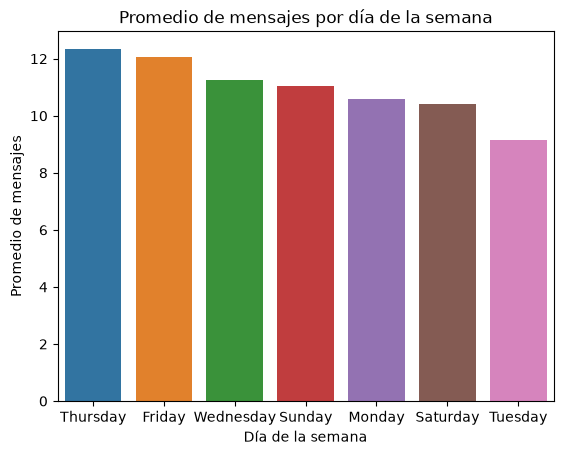

In [27]:
sns.barplot(
    x=promedio_mensajes_por_dia.index,
    y=promedio_mensajes_por_dia['promedio_mensajes'],
    order=promedio_mensajes_por_dia.index,
    palette='tab10',
    hue=promedio_mensajes_por_dia.index,
)
plt.xlabel('Día de la semana')
plt.ylabel('Promedio de mensajes')
plt.title('Promedio de mensajes por día de la semana')
plt.show()


### 4.2 ¿Hay un patron semanal?
Parecería que no existe un patrón tan claro en la actividad del grupo a lo largo de la semana, aun que se puede observar como los dias entre semana (especificamente de miercoles a viernes) suelen tener la mayor actividad de mensaje y luego va bajando durante el fin de semana e inicios de la semana siguiente.

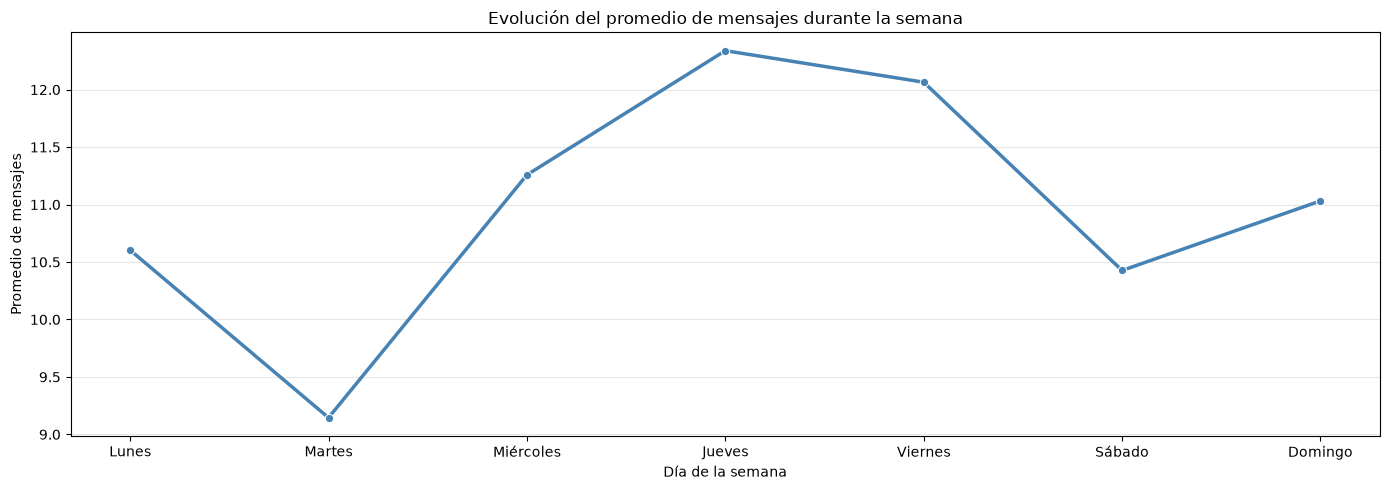

,dia,promedio_mensajes
dia_semana,,
Monday,Lunes,10.603175
Tuesday,Martes,9.145161
Wednesday,Miércoles,11.258065
Thursday,Jueves,12.338710
Friday,Viernes,12.064516
Saturday,Sábado,10.426230
Sunday,Domingo,11.031746


In [28]:
# Evolución del promedio de mensajes a lo largo de la semana
dias_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
nombres_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

promedio_semanal = (
    promedio_mensajes_por_dia.reindex(dias_semana)
    .assign(dia=nombres_dias)
)

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=promedio_semanal,
    x='dia',
    y='promedio_mensajes',
    marker='o',
    linewidth=2.5,
    color='steelblue'
)

plt.title('Evolución del promedio de mensajes durante la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Promedio de mensajes')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

promedio_semanal[['dia', 'promedio_mensajes']]

### 4.3 ¿Y por hora del día?

Podemos ver en el mapa de calor que la actividad de este grupo es mas fuerte entre las 8 y 11 (probablemente por que son las horas en las que se mandan los mensajes de "buenos días"). Claramente las horas donde hay menos mensajes son en la madrugada o muy tarde en la noche.

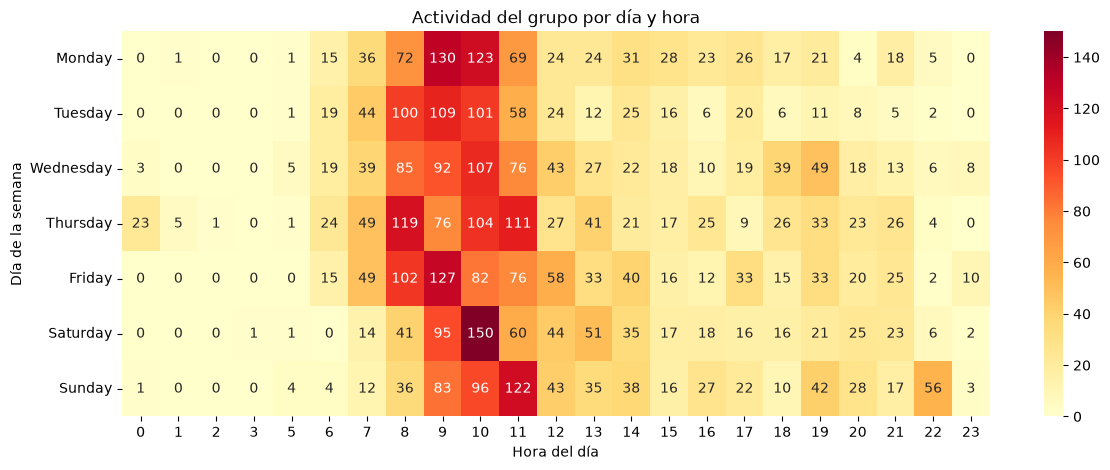

In [29]:
chat['dia_semana'] = pd.Categorical(
    chat['dia_semana'],
    categories=[
        'Monday', 'Tuesday', 'Wednesday',
        'Thursday', 'Friday', 'Saturday', 'Sunday'
    ],
    ordered=True
)

actividad = chat.pivot_table(
    index='dia_semana',
    columns='hora',
    values='mensaje',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(14, 5))
sns.heatmap(actividad, cmap='YlOrRd', annot=True, fmt='g')

plt.title('Actividad del grupo por día y hora')
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.show()

Si nos fijamos en el segundo gráfico, podemos ver la distribución de los mensajes por hora para cada día de la semana, lo que nos permite ver que los datos siguen una distribución parecida todos los días y que siguen una distribución normal con picos en las horas de mayor actividad.

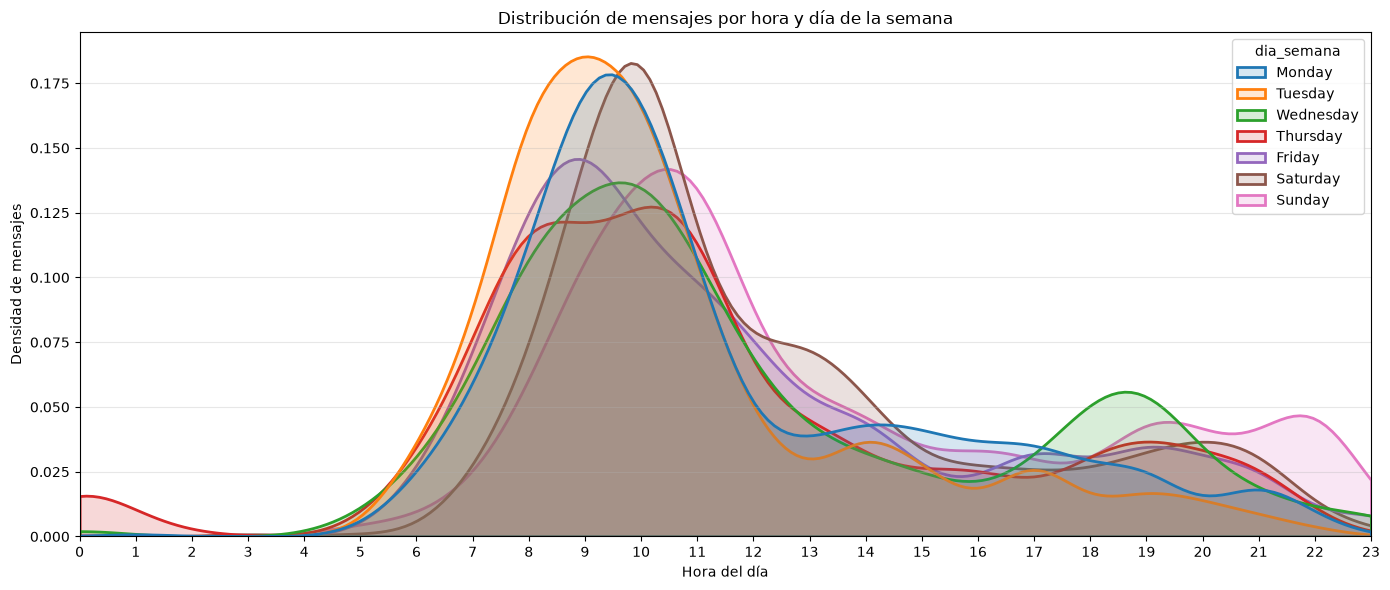

In [30]:
# Distribución de los mensajes por hora para cada día de la semana
plt.figure(figsize=(14, 6))
sns.kdeplot(
    data=chat,
    x='hora',
    hue='dia_semana',
    hue_order=dias_semana,
    common_norm=False,
    bw_adjust=0.7,
    fill=True,
    alpha=0.18,
    linewidth=2,
    clip=(0, 23)
)

plt.title('Distribución de mensajes por hora y día de la semana')
plt.xlabel('Hora del día')
plt.ylabel('Densidad de mensajes')
plt.xticks(range(24))
plt.xlim(0, 23)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Y en general?

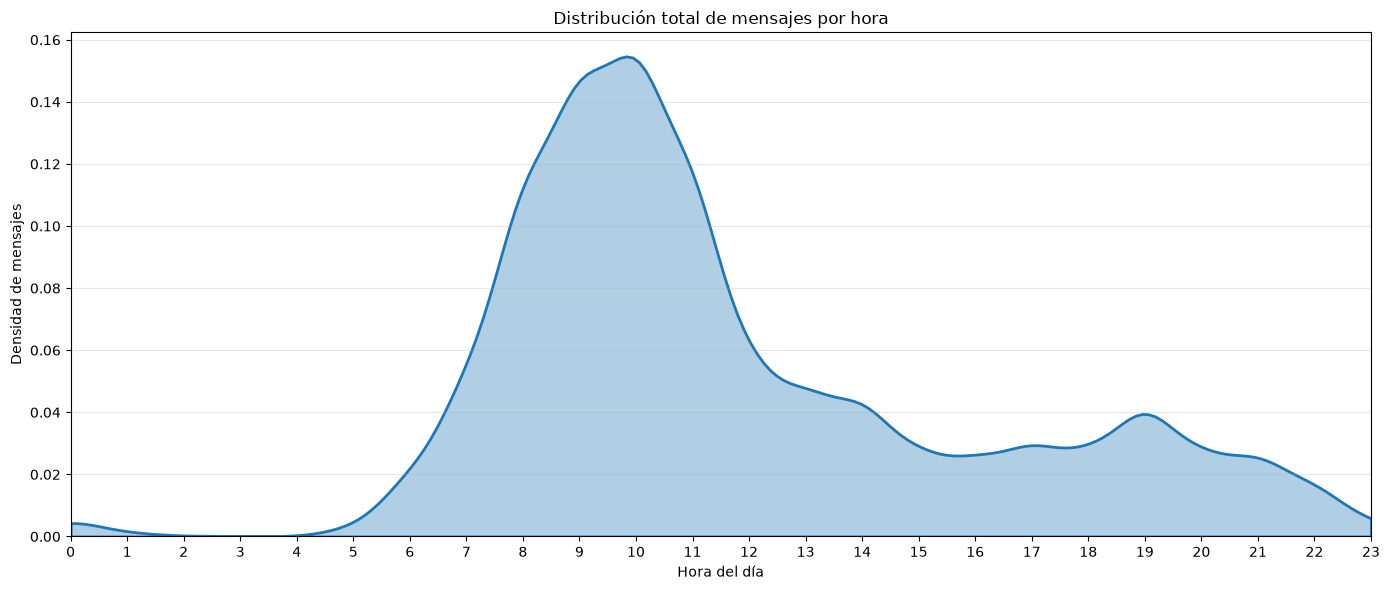

In [31]:
# Distribución total de los mensajes por hora
plt.figure(figsize=(14, 6))
sns.kdeplot(
    data=chat,
    x='hora',
    fill=True,
    alpha=0.35,
    linewidth=2,
    bw_adjust=0.7,
    clip=(0, 23)
)

plt.title('Distribución total de mensajes por hora')
plt.xlabel('Hora del día')
plt.ylabel('Densidad de mensajes')
plt.xticks(range(24))
plt.xlim(0, 23)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 ¿Que palabras son las más usadas por cada usuario?  

In [32]:
docs = nlp.pipe(chat["mensaje"].fillna(""))

palabras_por_usuario = {}


omitted_words = ["omitted", "sticker", 'deleted', 'removed', 'message', 'was', 'edited', 'anonimo']

for usuario, doc in zip(chat["remitente"], docs):
    palabras = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and token.lemma_ not in omitted_words
    ]

    palabras_por_usuario.setdefault(usuario, []).extend(palabras)

# Contar las palabras por usuario
conteo_palabras_por_usuario = {usuario: Counter(palabras) for usuario, palabras in palabras_por_usuario.items()}

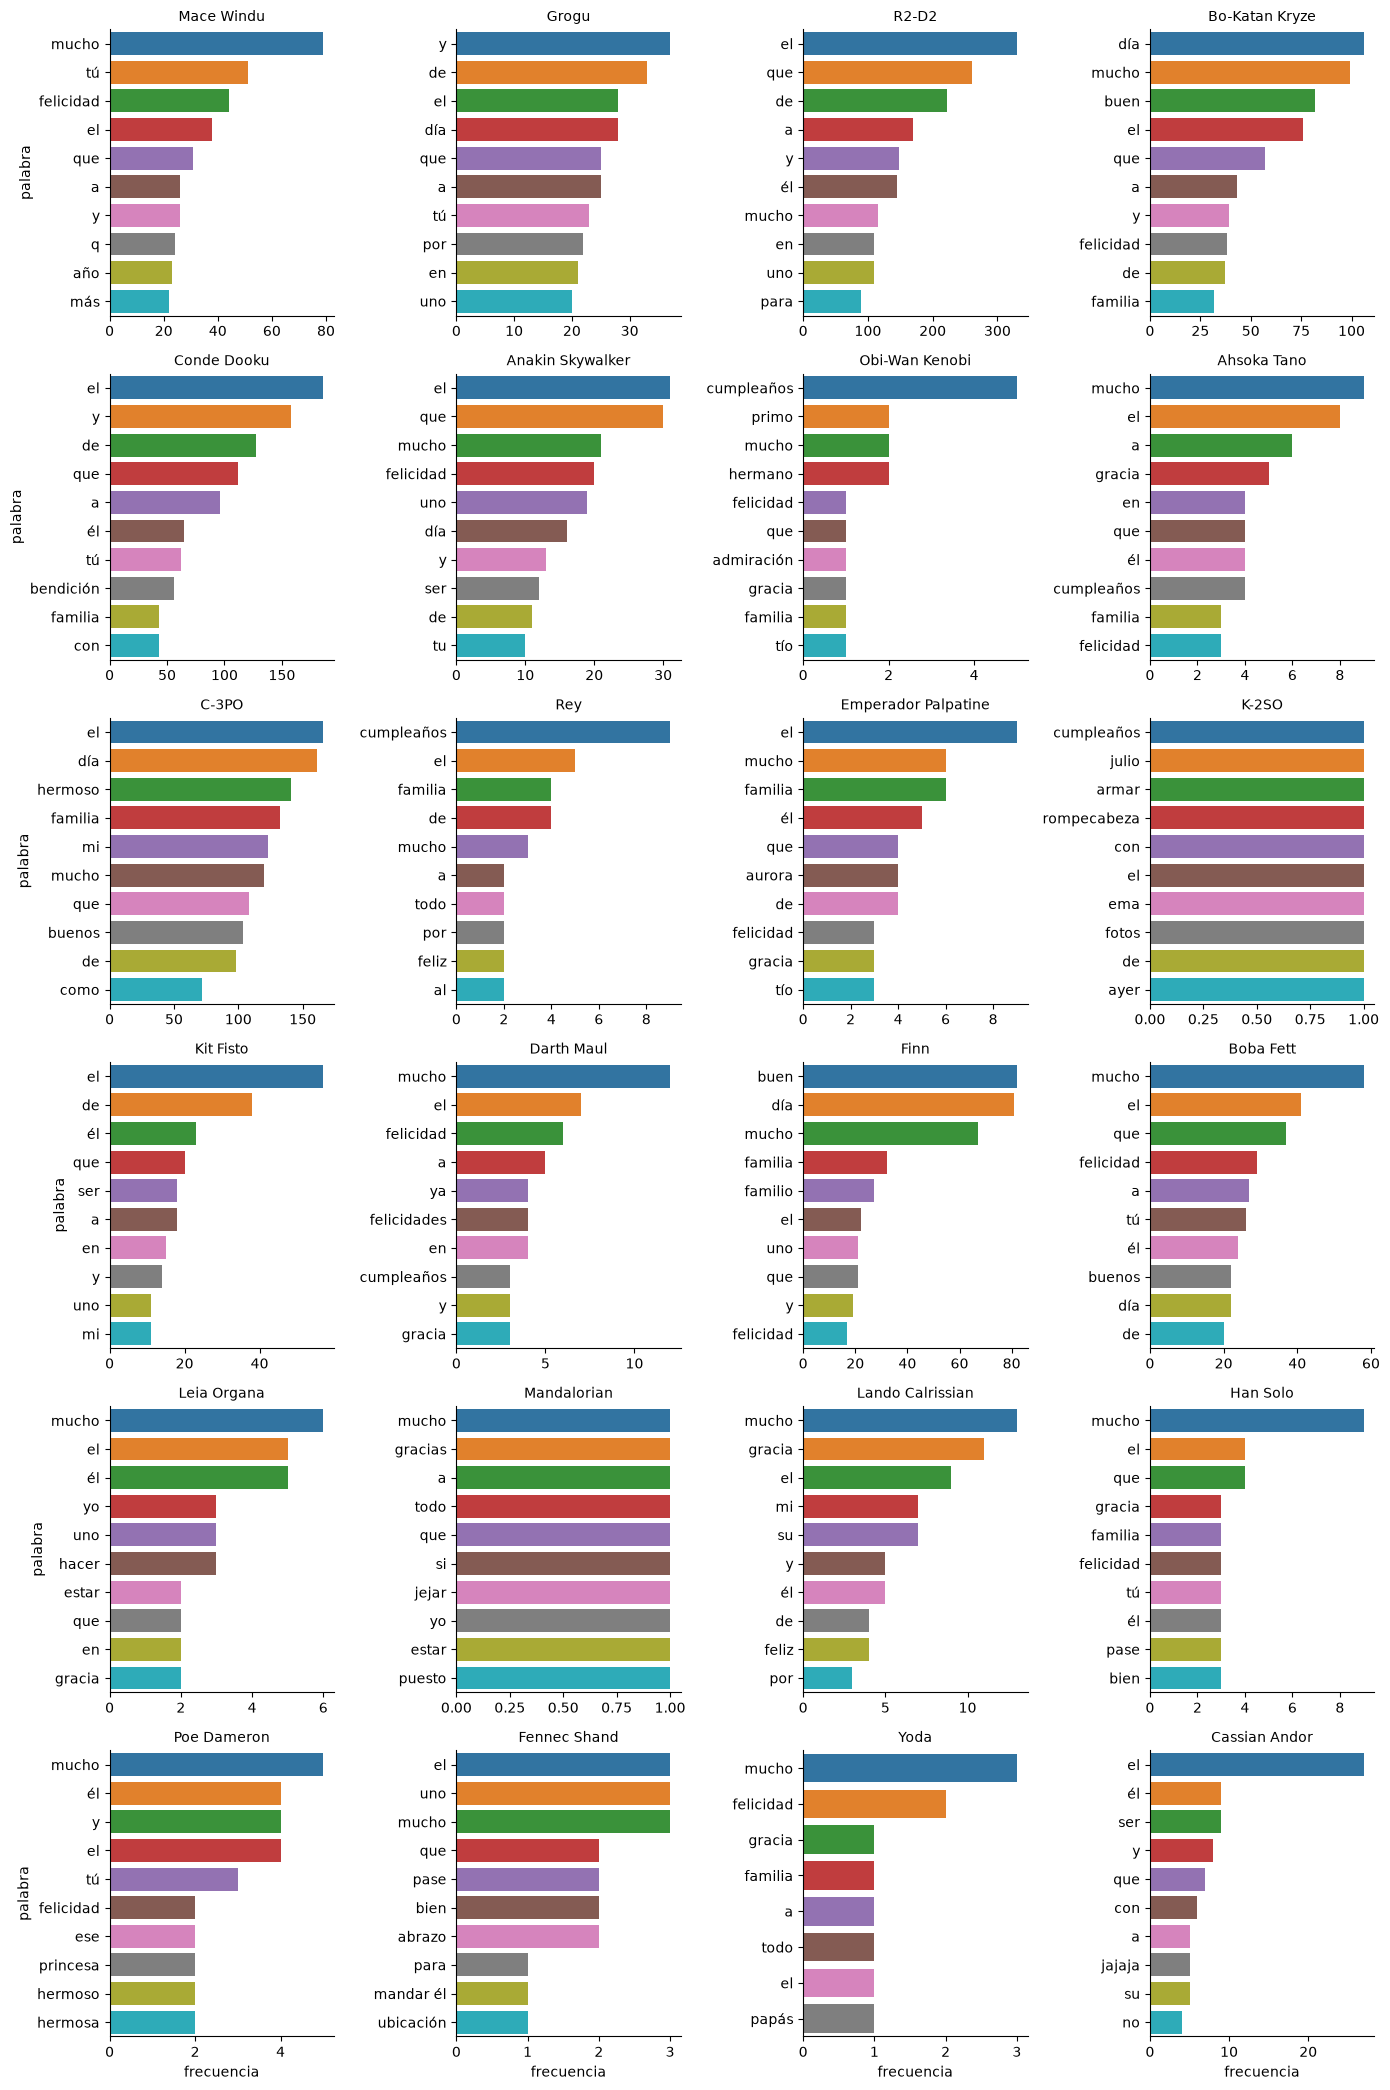

In [34]:
# Top 10 palabras más usadas por cada usuario
registros_palabras = []

for usuario, conteo in conteo_palabras_por_usuario.items():
    for palabra, frecuencia in conteo.most_common(10):
        registros_palabras.append({
            "remitente": usuario,
            "palabra": palabra,
            "frecuencia": frecuencia
        })

palabras_mas_usadas = pd.DataFrame(registros_palabras)

grid = sns.FacetGrid(
    palabras_mas_usadas,
    col="remitente",
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3.5
)
grid.map_dataframe(sns.barplot, x="frecuencia", y="palabra", hue="palabra", palette="tab10", legend=False)
grid.set_titles("{col_name}")
grid.tight_layout()
plt.show()

### 5.2 ¿Y en general? 

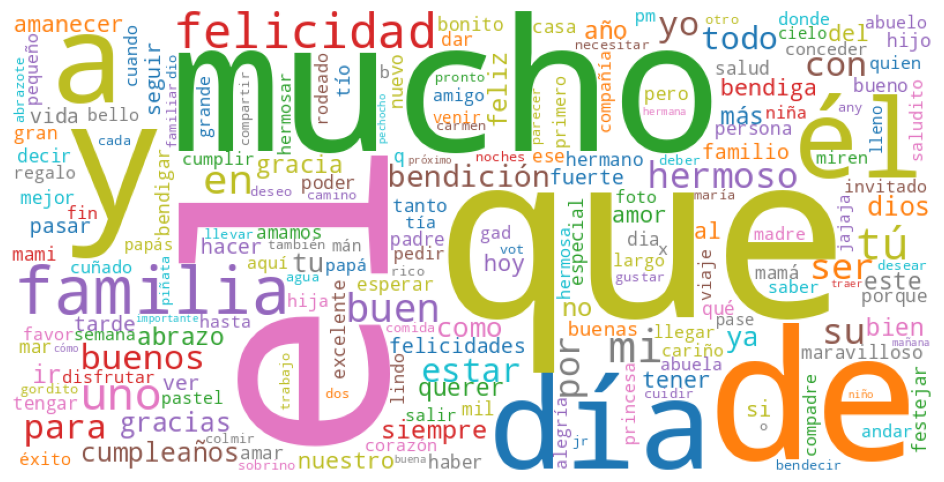

In [35]:
# Frecuencia de palabras combinando a todos los usuarios del grupo
conteo_palabras_general = Counter()
for conteo in conteo_palabras_por_usuario.values():
    conteo_palabras_general.update(conteo)

wc = wordcloud.WordCloud(width=800, height=400, background_color="white", colormap="tab10")
plt.figure(figsize=(12, 6))
plt.imshow(wc.generate_from_frequencies(conteo_palabras_general))
plt.axis("off")
plt.show()

### 5.3 ¿Que palabras son las más usadas en el grupo que no sean *stop words*?

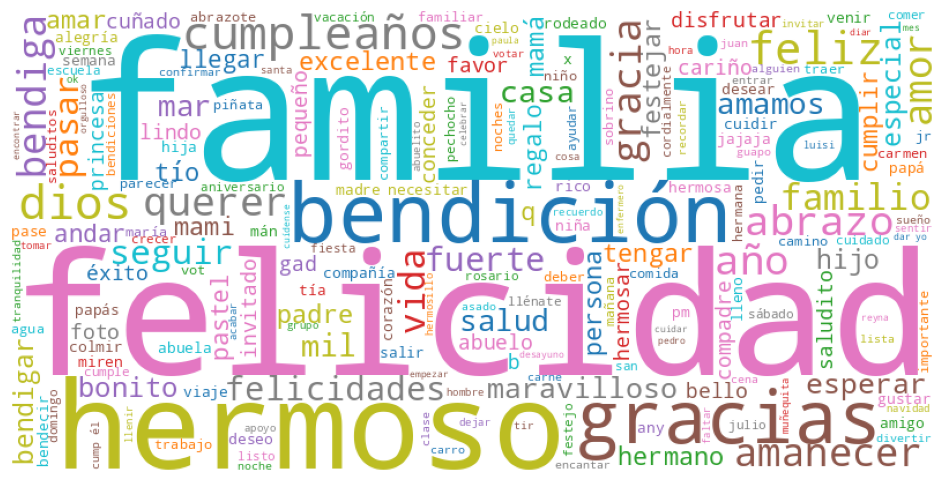

In [36]:
palabras_paro = nlp.Defaults.stop_words
conteo_palabras_filtrado = Counter({palabra: frecuencia for palabra, frecuencia in conteo_palabras_general.items() if palabra not in palabras_paro})

wc = wordcloud.WordCloud(width=800, height=400, background_color="white", colormap="tab10")
plt.figure(figsize=(12, 6))
plt.imshow(wc.generate_from_frequencies(conteo_palabras_filtrado))
plt.axis("off")
plt.show()

### 5.4 ¿Cuales son los adjetivos más usados?

Como se puede ver en el cloudword, hay algunos adjetivos que se repiten con mayor frecuencia y hay otros que no son adjetivos pero el modelo de spacy los toma como si lo fueran.

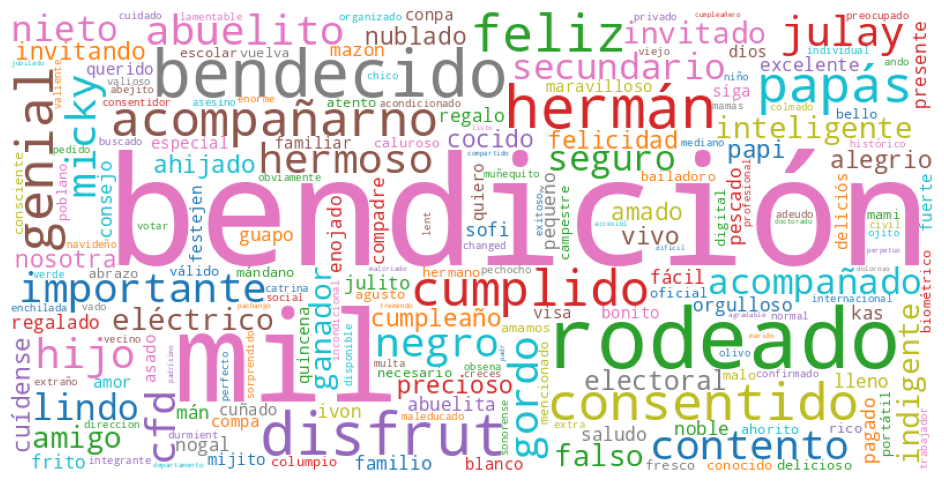

In [37]:
adjetivos_mas_usados = {}

omitted_words = ["omitted", "sticker", 'deleted', 'removed', 'message', 'was', 'edited', 'anonimo']

for usuario, doc in zip(chat["remitente"], nlp.pipe(chat["mensaje"].fillna(""))):
    adjetivos = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and token.pos_ == "ADJ"
        and token.lemma_ not in omitted_words
    ]

    adjetivos_mas_usados.setdefault(usuario, []).extend(adjetivos)

conteo_adjetivos_por_usuario = {usuario: Counter(adjetivos) for usuario, adjetivos in adjetivos_mas_usados.items()}

palabras_paro = nlp.Defaults.stop_words
conteo_adjetivos_filtrado = Counter({
    palabra: frecuencia
    for contador in conteo_adjetivos_por_usuario.values()
    for palabra, frecuencia in contador.items()
    if palabra not in palabras_paro
})

wc = wordcloud.WordCloud(width=800, height=400, background_color="white", colormap="tab10")
plt.figure(figsize=(15, 6))
plt.imshow(wc.generate_from_frequencies(conteo_adjetivos_filtrado))
plt.axis("off")
plt.show()

### ¿Qué otras preguntas interesantes puedes responder con los datos que tienes? ¿Qué otras gráficas o análisis puedes hacer?

Algunas preguntas interesantes podrían ser:
- ¿Cuáles son los temas más discutidos en el grupo?
- ¿Qué palabras o frases son más comunes en el grupo? (esto pudieramos hacerlo usando n-gramas)
- ¿Qué usuarios tienden a interactuar más entre sí?
- ¿Cuál es el sentimiento general de los mensajes en el grupo?
- ¿Qué usuarios suelen iniciar conversaciones en el grupo?
- ¿Qué usuarios tienen la mayor cantidad de mensajes eliminados o editados?

Se podria hacer un analisis de cada persona y con mas datos predecir la cantidad de mensajes que enviará en el futuro.

## Conclusiones
Como conclusión, podemos decir que este análisis nos ha permitido conocer los patrones de interacción y comportamiento dentro de un grupo de whatsapp. Claramente, estos resultados pueden variar drásticamente dependiendo del grupo, la cantidad de estudiantes y la relación entre sus miembros, no es lo mismo en este caso tomar un grupo de mi familia a tomar un grupo con amigos, compañeros de trabajo o el grupo de la MCD (estaría bueno observar cómo cambian los patrones en diferentes tipos de grupos).

Es interesante como con esta información podemos decir muchas cosas sobre el grupo y las personas que lo conforman y nos ayuda a entender como todo lo que hacemos o decimos puede explicar como somos. Tambien, se me hizo cuerioso como a pesar de que los nombres esten anonimizados, con el puro comportamiento pude identificar quienes son algunos de los miembros de mi familia por las palabras que usaba y la forma en que interactuaban.
